In [14]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    classification_report, confusion_matrix
)

print("All imports loaded!")

All imports loaded!


In [15]:
# Cell 2 — Load and prepare data
df = pd.read_csv('../data/dataset.csv')

df_encoded = df.copy()
df_encoded['competition'] = df_encoded['competition'].map(
    {'Low': 2, 'Medium': 1, 'High': 0})
df_encoded['category'] = df_encoded['category'].map(
    {'Electronics': 0, 'Clothing': 1, 'Food': 2, 'Health': 3})
df_encoded['timing'] = df_encoded['timing'].map(
    {'Festival': 1, 'Normal': 0})
df_encoded['region'] = df_encoded['region'].map(
    {'Urban': 1, 'Rural': 0})

X = df_encoded.drop('success', axis=1)
y = df_encoded['success']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Data ready — Train: {X_train.shape}, Test: {X_test.shape}")

Data ready — Train: (320, 6), Test: (80, 6)


In [16]:
# Cell 3 — Unlimited Decision Tree (will overfit)
dt_unlimited = DecisionTreeClassifier(random_state=42)
dt_unlimited.fit(X_train, y_train)

# Check BOTH train and test accuracy
train_acc_unlimited = accuracy_score(
    y_train, dt_unlimited.predict(X_train)
)
test_acc_unlimited = accuracy_score(
    y_test, dt_unlimited.predict(X_test)
)

print("=" * 45)
print("UNLIMITED DECISION TREE (no depth limit)")
print("=" * 45)
print(f"Tree depth reached: {dt_unlimited.get_depth()}")
print(f"Number of leaves:   {dt_unlimited.get_n_leaves()}")
print(f"\nTrain accuracy: {train_acc_unlimited:.4f} ({train_acc_unlimited*100:.1f}%)")
print(f"Test accuracy:  {test_acc_unlimited:.4f}  ({test_acc_unlimited*100:.1f}%)")
print(f"\nGap (overfit):  {(train_acc_unlimited - test_acc_unlimited)*100:.1f}%")

UNLIMITED DECISION TREE (no depth limit)
Tree depth reached: 9
Number of leaves:   49

Train accuracy: 1.0000 (100.0%)
Test accuracy:  0.8500  (85.0%)

Gap (overfit):  15.0%


In [17]:
# Cell 4 — Classification report (unlimited)
y_pred_unlimited = dt_unlimited.predict(X_test)

print("Classification Report — Unlimited Tree:")
print(classification_report(
    y_test, y_pred_unlimited,
    target_names=['Failure (0)', 'Success (1)']
))

Classification Report — Unlimited Tree:
              precision    recall  f1-score   support

 Failure (0)       0.82      0.90      0.86        41
 Success (1)       0.89      0.79      0.84        39

    accuracy                           0.85        80
   macro avg       0.85      0.85      0.85        80
weighted avg       0.85      0.85      0.85        80



In [18]:
# Cell 5 — Pruned Decision Tree (max_depth=5)
dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)
dt_model.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)

# Both train and test accuracy
train_acc_pruned = accuracy_score(
    y_train, dt_model.predict(X_train)
)
test_acc_pruned = accuracy_score(y_test, y_pred_dt)

print("=" * 45)
print("PRUNED DECISION TREE (max_depth=5)")
print("=" * 45)
print(f"Tree depth:       {dt_model.get_depth()}")
print(f"Number of leaves: {dt_model.get_n_leaves()}")
print(f"\nTrain accuracy: {train_acc_pruned:.4f} ({train_acc_pruned*100:.1f}%)")
print(f"Test accuracy:  {test_acc_pruned:.4f}  ({test_acc_pruned*100:.1f}%)")
print(f"\nGap (after fix): {(train_acc_pruned - test_acc_pruned)*100:.1f}%")

PRUNED DECISION TREE (max_depth=5)
Tree depth:       5
Number of leaves: 25

Train accuracy: 0.9469 (94.7%)
Test accuracy:  0.8500  (85.0%)

Gap (after fix): 9.7%


In [28]:
# Cell 6 — Overfitting comparison table
print("=" * 55)
print("OVERFITTING DEMONSTRATION — SIDE BY SIDE")
print("=" * 55)
print(f"{'Metric':<20} {'Unlimited Tree':>15} {'Pruned Tree':>15}")
print("-" * 55)
print(f"{'Train Accuracy':<20} {train_acc_unlimited*100:>14.1f}% {train_acc_pruned*100:>14.1f}%")
print(f"{'Test Accuracy':<20} {test_acc_unlimited*100:>14.1f}% {test_acc_pruned*100:>14.1f}%")
print(f"{'Gap':<20} {(train_acc_unlimited-test_acc_unlimited)*100:>14.1f}% {(train_acc_pruned-test_acc_pruned)*100:>14.1f}%")
print(f"{'Tree Depth':<20} {dt_unlimited.get_depth():>15} {dt_model.get_depth():>15}")
print(f"{'Num Leaves':<20} {dt_unlimited.get_n_leaves():>15} {dt_model.get_n_leaves():>15}")
print("=" * 55)
print(f"Conclusion: Pruning reduced the gap from {(train_acc_unlimited - test_acc_unlimited)*100:.1f}% to {(train_acc_pruned - test_acc_pruned)*100:.1f}%")
print("This proves overfitting was present and has been fixed.")

OVERFITTING DEMONSTRATION — SIDE BY SIDE
Metric                Unlimited Tree     Pruned Tree
-------------------------------------------------------
Train Accuracy                100.0%           94.7%
Test Accuracy                  85.0%           85.0%
Gap                            15.0%            9.7%
Tree Depth                         9               5
Num Leaves                        49              25
Conclusion: Pruning reduced the gap from 15.0% to 9.7%
This proves overfitting was present and has been fixed.


In [20]:
# Cell 7 — Classification report (pruned)
print("Classification Report — Pruned Tree (max_depth=5):")
print(classification_report(
    y_test, y_pred_dt,
    target_names=['Failure (0)', 'Success (1)']
))

Classification Report — Pruned Tree (max_depth=5):
              precision    recall  f1-score   support

 Failure (0)       0.84      0.88      0.86        41
 Success (1)       0.86      0.82      0.84        39

    accuracy                           0.85        80
   macro avg       0.85      0.85      0.85        80
weighted avg       0.85      0.85      0.85        80



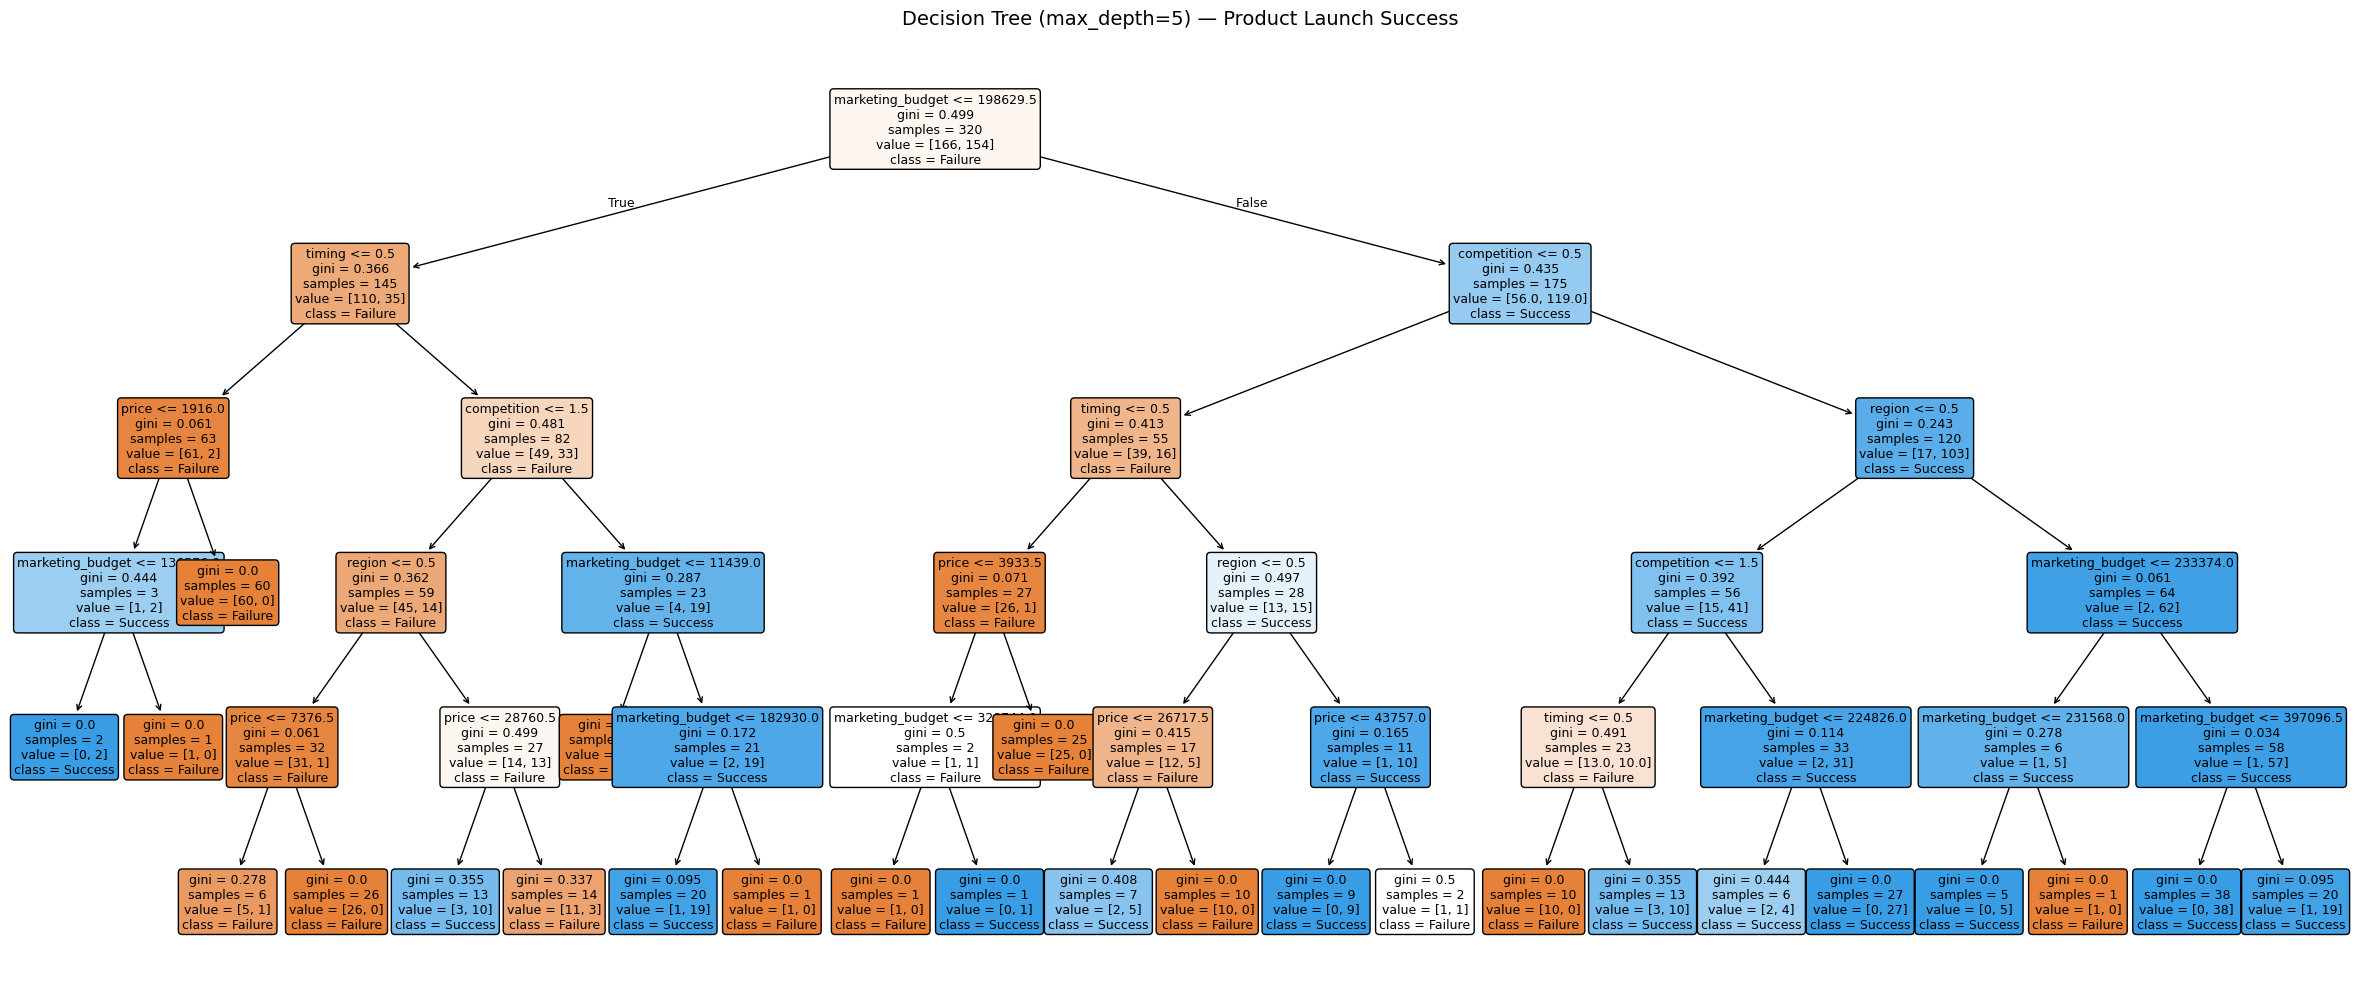

Decision tree saved to plots/decision_tree.png


In [21]:
# Cell 8 — Visualize pruned Decision Tree
plt.figure(figsize=(24, 10))

plot_tree(
    dt_model,
    feature_names=list(X_train.columns),
    class_names=['Failure', 'Success'],
    filled=True,
    rounded=True,
    fontsize=9,
    impurity=True,
    proportion=False
)

plt.title(
    'Decision Tree (max_depth=5) — Product Launch Success',
    fontsize=14, pad=20
)
plt.tight_layout()
plt.savefig(
    '../plots/decision_tree.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

print("Decision tree saved to plots/decision_tree.png")

In [22]:
# Cell 9 — Extract top split feature
feature_names = list(X_train.columns)
top_feature = feature_names[dt_model.tree_.feature[0]]
top_threshold = dt_model.tree_.threshold[0]

print("=" * 50)
print("WHAT THE DECISION TREE LEARNED")
print("=" * 50)
print(f"\nRoot node (first question asked):")
print(f"  Feature: {top_feature}")
print(f"  Threshold: {top_threshold:.2f}")
print(f"\nIn plain English:")
print(f"  'Is {top_feature} <= {top_threshold:.1f}?'")
print(f"\nFeatures used in tree:")
used = set(dt_model.tree_.feature[dt_model.tree_.feature >= 0])
for i in used:
    print(f"  - {feature_names[i]}")

WHAT THE DECISION TREE LEARNED

Root node (first question asked):
  Feature: marketing_budget
  Threshold: 198629.50

In plain English:
  'Is marketing_budget <= 198629.5?'

Features used in tree:
  - price
  - marketing_budget
  - competition
  - timing
  - region


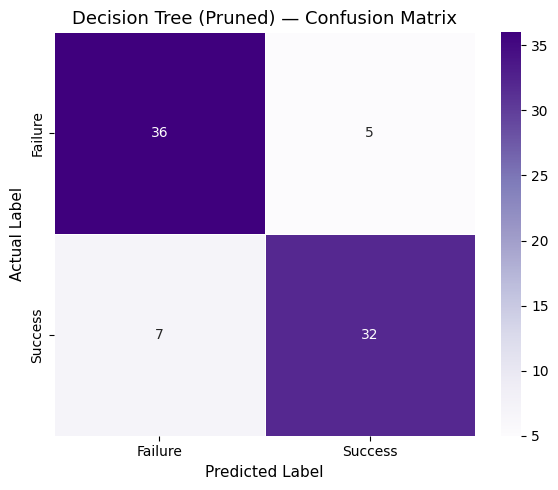

Confusion matrix saved!

TN=36  FP=5
FN=7  TP=32


In [23]:
# Cell 10 — Confusion matrix (pruned tree)
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_dt,
            annot=True,
            fmt='d',
            cmap='Purples',
            xticklabels=['Failure', 'Success'],
            yticklabels=['Failure', 'Success'],
            linewidths=0.5)

plt.title('Decision Tree (Pruned) — Confusion Matrix', fontsize=13)
plt.ylabel('Actual Label', fontsize=11)
plt.xlabel('Predicted Label', fontsize=11)
plt.tight_layout()
plt.savefig('../plots/dt_confusion_matrix.png', dpi=150)
plt.show()

print("Confusion matrix saved!")
print(f"\nTN={cm_dt[0,0]}  FP={cm_dt[0,1]}")
print(f"FN={cm_dt[1,0]}  TP={cm_dt[1,1]}")

In [ ]:
# Cell 11 — Results dictionary (both models)

# Paste your Day 3 numbers here
results = {}
results['Logistic Regression'] = {
    'accuracy':  0.8750,
    'precision': 0.8919,
    'recall':    0.8462,
    'f1':        0.8684
}

# Decision Tree (pruned) — calculated live today
results['Decision Tree'] = {
    'accuracy':  round(accuracy_score(y_test, y_pred_dt), 4),
    'precision': round(precision_score(y_test, y_pred_dt), 4),
    'recall':    round(recall_score(y_test, y_pred_dt), 4),
    'f1':        round(f1_score(y_test, y_pred_dt), 4)
}
# Print comparison so far
print("=" * 55)
print("RESULTS SO FAR (2 of 3 models)")
print("=" * 55)
for model, metrics in results.items():
    print(f"\n{model}:")
    for metric, val in metrics.items():
        print(f"  {metric:12s}: {val:.4f}  ({val*100:.1f}%)")


RESULTS SO FAR (2 of 3 models)

Logistic Regression:
  accuracy    : 0.0000  (0.0%)
  precision   : 0.0000  (0.0%)
  recall      : 0.0000  (0.0%)
  f1          : 0.0000  (0.0%)

Decision Tree:
  accuracy    : 0.8500  (85.0%)
  precision   : 0.8649  (86.5%)
  recall      : 0.8205  (82.0%)
  f1          : 0.8421  (84.2%)


In [25]:
# Cell 12 — Print DT numbers to note down
dt_accuracy  = results['Decision Tree']['accuracy']
dt_precision = results['Decision Tree']['precision']
dt_recall    = results['Decision Tree']['recall']
dt_f1        = results['Decision Tree']['f1']

print("Write these down for Day 5:")
print(f"  DT accuracy:  {dt_accuracy}")
print(f"  DT precision: {dt_precision}")
print(f"  DT recall:    {dt_recall}")
print(f"  DT f1:        {dt_f1}")

print("\nAlso note overfitting numbers:")
print(f"  Unlimited tree test accuracy:  {test_acc_unlimited*100:.1f}%")
print(f"  Pruned tree test accuracy:     {test_acc_pruned*100:.1f}%")

Write these down for Day 5:
  DT accuracy:  0.85
  DT precision: 0.8649
  DT recall:    0.8205
  DT f1:        0.8421

Also note overfitting numbers:
  Unlimited tree test accuracy:  85.0%
  Pruned tree test accuracy:     85.0%


In [26]:
# Cell 13 — Confirm output files
import os

files = [
    '../plots/decision_tree.png',
    '../plots/dt_confusion_matrix.png'
]

for f in files:
    status = "EXISTS" if os.path.exists(f) else "MISSING"
    size = os.path.getsize(f) if os.path.exists(f) else 0
    print(f"{status}: {f}  ({size:,} bytes)")


EXISTS: ../plots/decision_tree.png  (579,710 bytes)
EXISTS: ../plots/dt_confusion_matrix.png  (33,594 bytes)
